# Лабораторная работа № 1
## Анализ и прогнозирование временных рядов на примере розничных продаж

**Предмет:** предиктивная аналитика · **Данные:** `retail_sales_mock_data.csv` · **Частота:** месяц · **Модели:** ARIMA, SARIMAX

**Структура (строго по заданию):**

1. **2.1. Разведочный анализ данных:** качество, визуализации, классическая/STL-декомпозиция, FFT, вейвлет Морле, сопоставление методов.
2. **2.2. Прогнозные модели:** ADF/ACF/PACF, аргументация параметров, ARIMA и несколько SARIMAX, временное разбиение, валидация, выбор конфигурации.
3. **2.3. Оценка качества:** MSE, R², MAE, WAPE, AIC/BIC, контрольный прогноз, проверка нормальности/автокорреляции/гомоскедастичности ошибок, графики и таблицы.
4. **2.4. Интерпретация и документирование:** проверяемый горизонт, прогноз следующего года, интервалы неопределённости, практическая интерпретация и ограничения.

> **Методологический принцип:** прогнозы нельзя оценивать на наблюдениях, которые использовались при подгонке. **2023 год не используется ни для обучения, ни для выбора спецификации.** 2020–2021 гг. — первоначальное обучение, 2022 г. — валидация, 2023 г. — финальный независимый тест. После тестирования выбранная **заранее** модель переобучается на всём доступном ряде для прогноза 2024 года.

> **О воспроизводимости:** ноутбук самодостаточен. Сначала он ищет CSV рядом с собой; если файл не найден, использует **точную резервную копию исходных 48 строк**, встроенную ниже. Интернет и Google Colab не требуются. Используются `numpy`, `pandas`, `matplotlib`, `scipy`, `statsmodels`, `scikit-learn`, `IPython` (без `pmdarima` и `PyWavelets`).

**Примечание к формулировке задания:** в пункте 2.4 текста встречается «пять основных пунктов», хотя в документе перечислены четыре подпункта 2.1–2.4. Выводы даны по каждому из четырёх требуемых подпунктов.

### Подготовка окружения и фиксация воспроизводимости

Все библиотеки импортируются один раз. Для спектрального и вейвлет-анализа применяется `scipy`, а для ARIMA/SARIMAX — `statsmodels`, как в материалах преподавателя. Графики подписаны на русском языке; единица продаж в источнике не уточнена, поэтому **денежная валюта не предполагается**.

In [3]:
# %matplotlib inline
# Основные зависимости; достаточно стандартного окружения для анализа временных рядов.
import io
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy import signal, stats
from scipy.signal import fftconvolve
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan, het_arch
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

np.random.seed(42)
warnings.filterwarnings('ignore', category=ConvergenceWarning)
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'figure.figsize':(12,4.5),
                     'axes.spines.top':False,'axes.spines.right':False,
                     'axes.grid':True,'grid.alpha':0.22,'figure.dpi':105})

---
# 1. разведочный анализ данных (EDA)

Цели этапа: проверить целостность исходного ряда, выявить тренд, календарные эффекты, возможные выбросы, сезонность и стационарность; сопоставить декомпозицию во времени, в частотной области и во временно-частотном представлении.



## 1.1. Загрузка исходных данных и проверка структуры

In [20]:
raw_df = pd.read_csv('retail_sales_mock_data.csv', parse_dates=['Date'])
df = raw_df.sort_values('Date').set_index('Date').asfreq('MS')
y = df['SalesAmount'].astype(float)

In [23]:
print('Размер:', df.shape, '| диапазон:', df.index.min().date(), '—', df.index.max().date())
print('Частота:', df.index.freqstr, '| пропуски:', df.isna().sum().to_dict())
print('Количество рекламных месяцев:', int(df.Promotion.sum()),
      '| праздничных месяцев:', int(df.HolidayMonth.sum()))
display(df.head(7))
display(df.describe().round(2))

Размер: (48, 3) | диапазон: 2020-01-01 — 2023-12-01
Частота: MS | пропуски: {'SalesAmount': 0, 'Promotion': 0, 'HolidayMonth': 0}
Количество рекламных месяцев: 6 | праздничных месяцев: 4


,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0
2020-06-01,9131,1,0
2020-07-01,9089,0,0


,SalesAmount,Promotion,HolidayMonth
count,48.00,48.00,48.00
mean,11768.54,0.12,0.08
std,2257.54,0.33,0.28
min,7783.00,0.00,0.00
25%,10219.75,0.00,0.00
50%,11851.00,0.00,0.00
75%,13014.00,0.00,0.00
max,17996.00,1.00,1.00


### Разделение по времени без перемешивания

Для реального предсказания нельзя случайно смешивать будущие и прошлые месяцы. Первые 24 наблюдения формируют обучающую часть, следующие 12 - валидационную, последние 12 - отложенную тестовую.

EDA и выбор признаков ниже выполняются на первых 36 месяцах (истории до 2023 года)

In [25]:
train = y.iloc[:24].copy()          # январь 2020 — декабрь 2021
valid = y.iloc[24:36].copy()        # январь 2022 — декабрь 2022
test = y.iloc[36:48].copy()         # январь 2023 — декабрь 2023
history = y.iloc[:36].copy()        # история  (для EDA)
assert len(train) == 24 and len(valid) == 12 and len(test) == 12

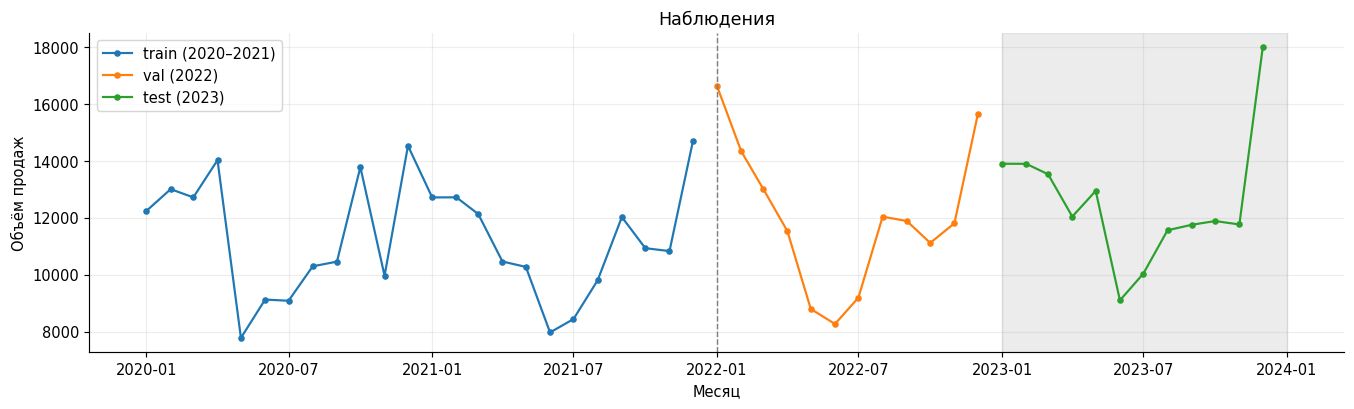

In [29]:
fig, ax = plt.subplots(figsize=(13,4))
ax.plot(train.index,train,marker='o',ms=3.5,label='train (2020–2021)')
ax.plot(valid.index,valid,marker='o',ms=3.5,label='val (2022)')
ax.plot(test.index,test,marker='o',ms=3.5,label='test (2023)')
ax.axvspan(test.index.min(),test.index.max()+pd.offsets.MonthBegin(1),alpha=0.15,color='gray')
ax.axvline(valid.index.min(),color='gray',ls='--',lw=1)
ax.set(title='Наблюдения',xlabel='Месяц',ylabel='Объём продаж')
ax.legend(loc='upper left')

plt.tight_layout()
plt.show()

### Описательная статистика, общий вид, тренд и вариативность

Проверяем уровни продаж, разброс и средние значения по годам. Скользящие средние на 3 и 12 месяцев предназначены для диагностики, а не для прогнозирования

,count,mean,std,min,max,sum
Год,,,,,,
2020,12,11422.2,2240.0,7783.0,14534.0,137067.0
2021,12,11088.0,1901.5,7976.0,14696.0,133056.0
2022,12,12025.3,2596.6,8273.0,16623.0,144304.0


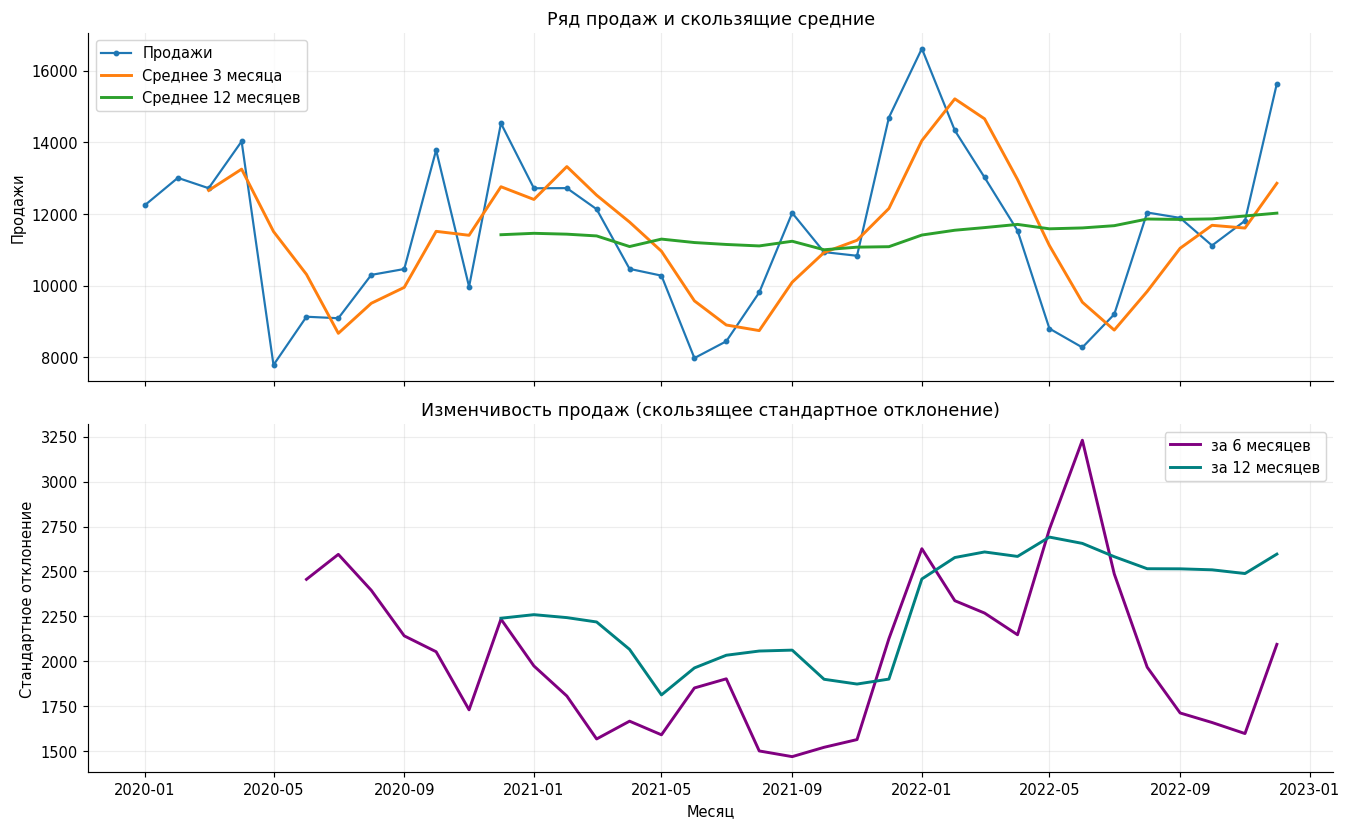

Среднее за 2020–2022: 11511.9; медиана: 11674.5; стандартное отклонение: 2233.2; CV = 19.4%.
Относительное изменение годового среднего 2022 к 2020: +5.3%.


In [33]:
yr = history.groupby(history.index.year).agg(['count','mean','std','min','max','sum'])
yr.index.name = 'Год'
display(yr.round(1))

fig,axs=plt.subplots(2,1,figsize=(13,8),sharex=True)
axs[0].plot(history.index,history.values,marker='o',ms=3,label='Продажи')
axs[0].plot(history.rolling(3).mean(),lw=2,label='Среднее 3 месяца')
axs[0].plot(history.rolling(12).mean(),lw=2,label='Среднее 12 месяцев')
axs[0].set(title='Ряд продаж и скользящие средние',ylabel='Продажи');axs[0].legend()
axs[1].plot(history.rolling(6).std(),color='purple',lw=2,label='за 6 месяцев')
axs[1].plot(history.rolling(12).std(),color='teal',lw=2,label='за 12 месяцев')
axs[1].set(title='Изменчивость продаж (скользящее стандартное отклонение)',xlabel='Месяц',ylabel='Стандартное отклонение')
axs[1].legend()
plt.tight_layout()
plt.show()

print(f'Среднее за 2020–2022: {history.mean():.1f}; медиана: {history.median():.1f}; '
      f'стандартное отклонение: {history.std():.1f}; CV = {history.std()/history.mean()*100:.1f}%.')
print(f'Относительное изменение годового среднего 2022 к 2020: '
      f'{(yr.loc[2022,"mean"]/yr.loc[2020,"mean"]-1)*100:+.1f}%.')

### Календарная сезонность и объясняющие признаки

Для каждого календарного месяца доступно только по 3 значения. Большие различия между месяцами могут говорить о годовом цикле, но малыe выборки **не позволяют** считать оценки точными причинными эффектами.

- `Promotion` не включаем в базовый прогноз - реальные промо-планы на следующий год в источнике отсутствуют
- индикатор `HolidayMonth` проверен - это декабрь, который известен заранее из календаря (поэтому его использование при прогнозе не создаёт утечки будущего)

In [34]:
mon = history.groupby(history.index.month).agg(['count','mean','std','min','max'])
mon.index.name = 'Месяц'
mon_names=['Янв','Фев','Мар','Апр','Май','Июн','Июл','Авг','Сен','Окт','Ноя','Дек']
mon['Название']=mon_names
display(mon[['Название','count','mean','std','min','max']].round(1))

,Название,count,mean,std,min,max
Месяц,,,,,,
1,Янв,3,13863.7,2401.3,12248.0,16623.0
2,Фев,3,13357.0,859.9,12724.0,14336.0
3,Мар,3,12627.0,451.1,12136.0,13023.0
4,Апр,3,12011.7,1827.8,10468.0,14030.0
5,Май,3,8954.0,1255.1,7783.0,10279.0
6,Июн,3,8460.0,599.8,7976.0,9131.0
7,Июл,3,8911.0,407.3,8445.0,9199.0
8,Авг,3,10717.7,1173.6,9810.0,12043.0
9,Сен,3,11462.3,867.4,10464.0,12031.0


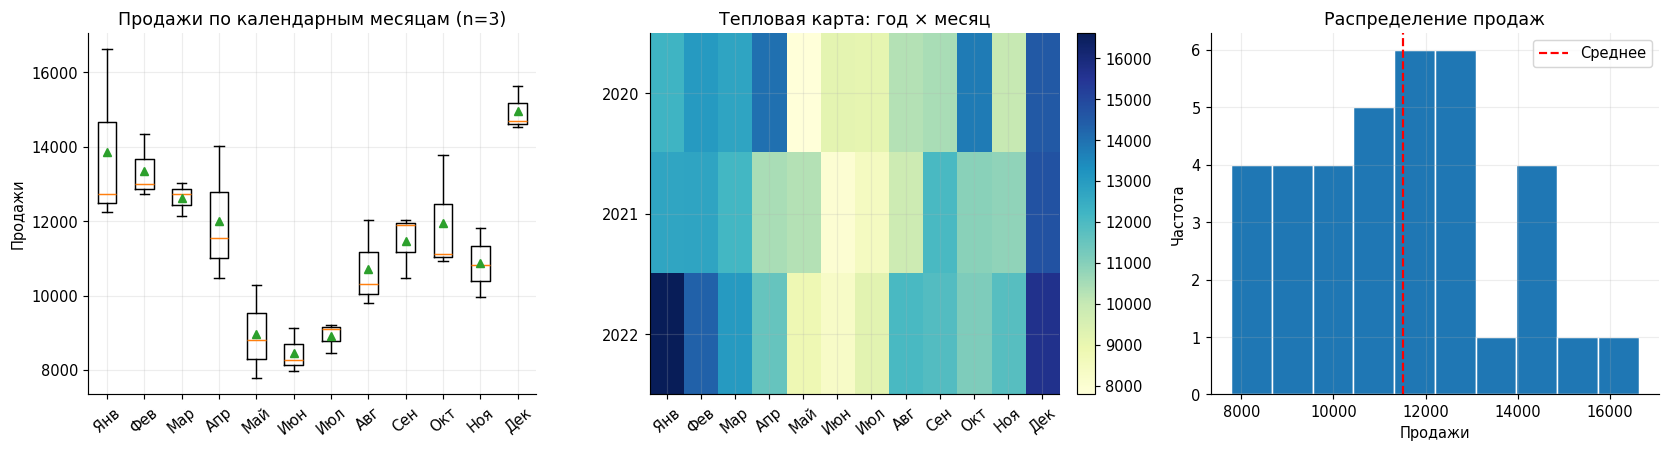

Максимальный средний месяц: Дек (14958); минимальный: Июн (8460).
Разница максимум–минимум: 6498 (76.8% относительно минимума).


In [37]:
pivot=history.to_frame('SalesAmount')
pivot['Год']=pivot.index.year
pivot['Месяц']=pivot.index.month
heat=pivot.pivot(index='Год',columns='Месяц',values='SalesAmount')

fig,ax=plt.subplots(1,3,figsize=(16,4.4))
ax[0].boxplot([history[history.index.month==m].values for m in range(1,13)],tick_labels=mon_names,showmeans=True)
ax[0].tick_params(axis='x',rotation=40)
ax[0].set(title='Продажи по календарным месяцам (n=3)',ylabel='Продажи')

im=ax[1].imshow(heat,cmap='YlGnBu',aspect='auto')
ax[1].set(xticks=np.arange(12),xticklabels=mon_names,yticks=np.arange(3),yticklabels=heat.index,title='Тепловая карта: год × месяц')
ax[1].tick_params(axis='x',rotation=40)
fig.colorbar(im,ax=ax[1],fraction=0.046,pad=0.04)

ax[2].hist(history,bins=10,edgecolor='white')
ax[2].axvline(history.mean(),ls='--',color='red',label='Среднее')
ax[2].set(title='Распределение продаж',xlabel='Продажи',ylabel='Частота');ax[2].legend()

plt.tight_layout()
plt.show()

print(f'Максимальный средний месяц: {mon.loc[mon["mean"].idxmax(),"Название"]} '
      f'({mon["mean"].max():.0f}); минимальный: '
      f'{mon.loc[mon["mean"].idxmin(),"Название"]} ({mon["mean"].min():.0f}).')
print(f'Разница максимум–минимум: {mon["mean"].max()-mon["mean"].min():.0f} '
      f'({(mon["mean"].max()/mon["mean"].min()-1)*100:.1f}% относительно минимума).')

### Корреляционные зависимости и предварительная стационарность

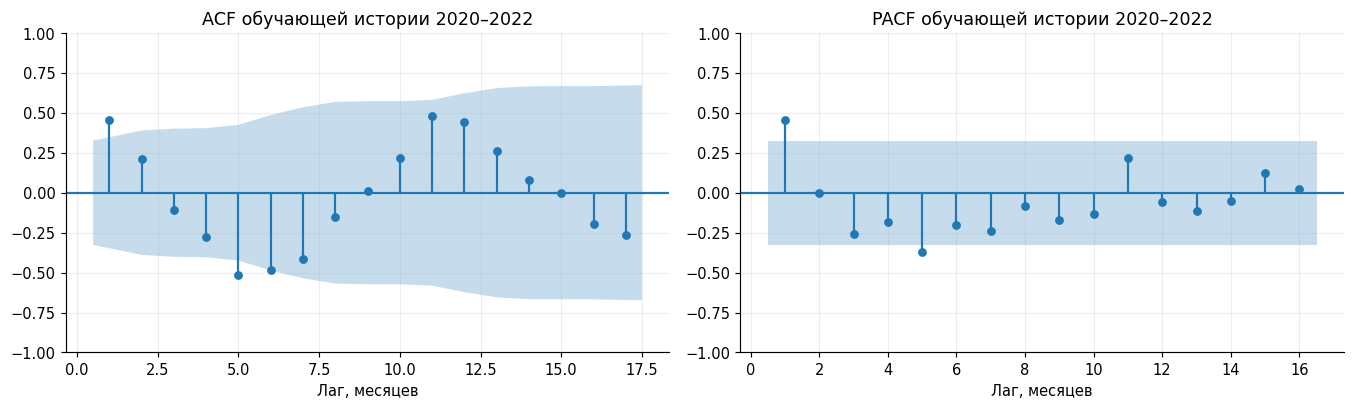

C:\Temp\ipykernel_18168\1433236006.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat,p,usedlag,nobs,crit,_=adfuller(s,autolag='AIC',maxlag=min(3,max(0,len(s)//4-1)))
C:\Temp\ipykernel_18168\1433236006.py:11: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat,p,usedlag,nobs,crit,_=adfuller(s,autolag='AIC',maxlag=min(3,max(0,len(s)//4-1)))
C:\Temp\ipykernel_18168\14

,Ряд,n,ADF,p-value,Лагов,Вывод при α=0.05
0,"Уровни, train (24)",24,-3.091,0.0272,0,нет оснований считать единичный корень
1,"Разность 1-го порядка, train (23)",23,-6.978,0.0000,0,нет оснований считать единичный корень
2,"Сезонная разность 12, history (24)",24,-5.228,0.0000,0,нет оснований считать единичный корень


In [38]:
fig,ax=plt.subplots(1,2,figsize=(13,4))
plot_acf(history,lags=17,ax=ax[0],zero=False)
plot_pacf(history,lags=16,ax=ax[1],method='ywm',zero=False)
ax[0].set(title='ACF обучающей истории 2020–2022',xlabel='Лаг, месяцев')
ax[1].set(title='PACF обучающей истории 2020–2022',xlabel='Лаг, месяцев')
plt.tight_layout()
plt.show()

def adf_row(name,series):
    s=series.dropna().astype(float)
    stat,p,usedlag,nobs,crit,_=adfuller(s,autolag='AIC',maxlag=min(3,max(0,len(s)//4-1)))
    return {'Ряд':name,'n':len(s),'ADF':stat,'p-value':p,'Лагов':usedlag,
            'Вывод при α=0.05':'нет оснований считать единичный корень' if p<0.05 else 'единичный корень не отвергается'}

adf_table=pd.DataFrame([
    adf_row('Уровни, train (24)',train),
    adf_row('Разность 1-го порядка, train (23)',train.diff()),
    adf_row('Сезонная разность 12, history (24)',history.diff(12))])
display(adf_table.round({'ADF':3,'p-value':4}))

- Анализ автокорреляционной функции (ACF) показал наличие положительной корреляции между соседними наблюдениями (ACF(1) ≈ 0,45), а также выраженной отрицательной корреляции на лагах около 5–7 месяцев. На сезонном лаге 12 наблюдается положительная автокорреляция около 0,44, что согласуется с гипотезой о наличии годовой сезонности. Однако из-за ограниченной длины временного ряда этот коэффициент не выходит за границы доверительного интервала, поэтому вывод о сезонности требует дополнительной проверки
- Частная автокорреляционная функция (PACF) демонстрирует статистически значимый коэффициент на первом лаге, что указывает на целесообразность рассмотрения авторегрессионных моделей первого порядка.
Для проверки наличия единичного корня применён расширенный тест Дики-Фуллера (ADF). Для исходного тренировочного ряда получено значение статистики −3,091 при `p-value = 0,0272`. На уровне значимости 5% нулевая гипотеза о наличии единичного корня отвергается
- Применение обычного и сезонного дифференцирования также приводит к отклонению нулевой гипотезы ADF. При этом исходный ряд уже не демонстрирует наличие обычного единичного корня, поэтому дополнительное дифференцирование не является обязательным и должно обосновываться улучшением прогнозных характеристик


Таким образом, результаты анализа позволяют рассматривать модели ARIMA с малым порядком авторегрессии и d=0, а также модели SARIMAX, учитывающие возможную годовую сезонность с периодом 12 месяцев

## 1.2 Декомпозиция ряда на компоненты тремя методами 

### Классическая аддитивная и мультипликативная декомпозиции, а также STL

Используем **period = 12**, что соответствует годовой сезонности ежемесячного ряда. Берём одинаковые 36 исторических месяцев (3 цикла)

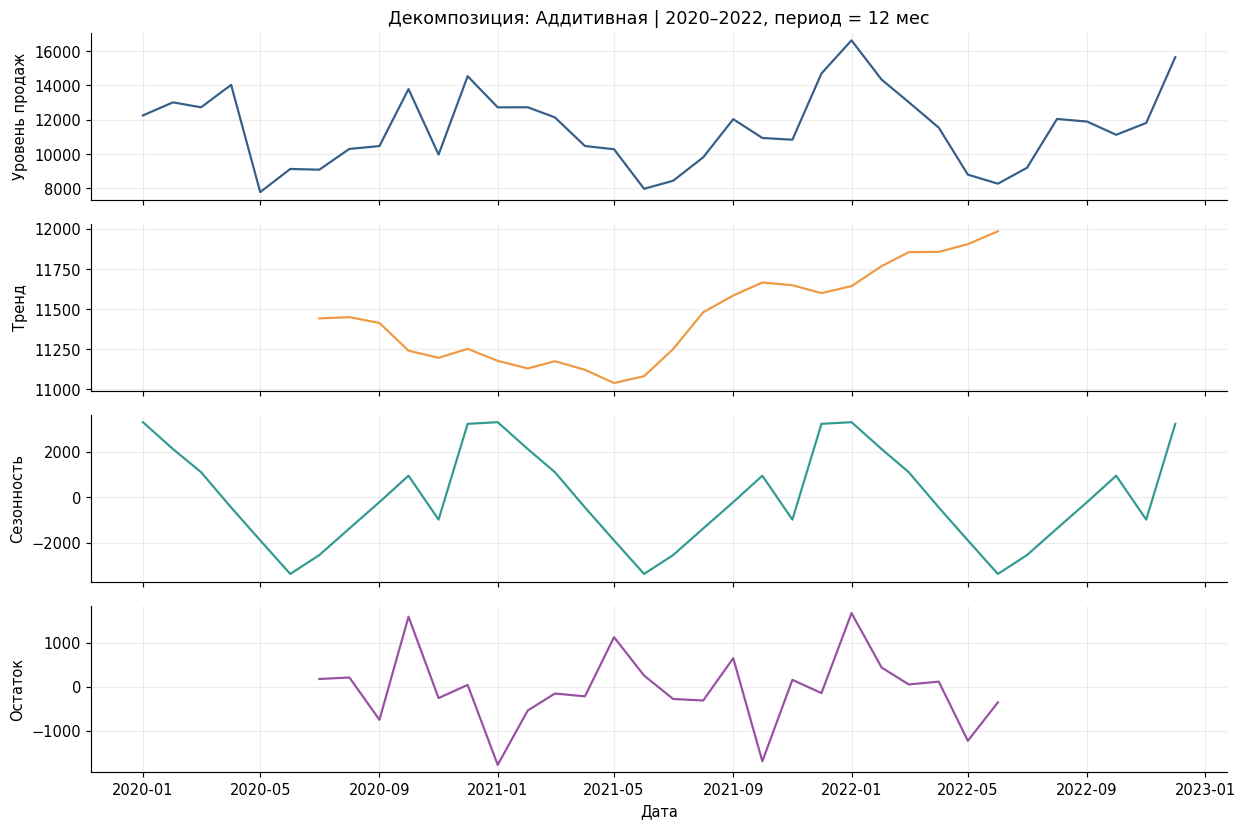

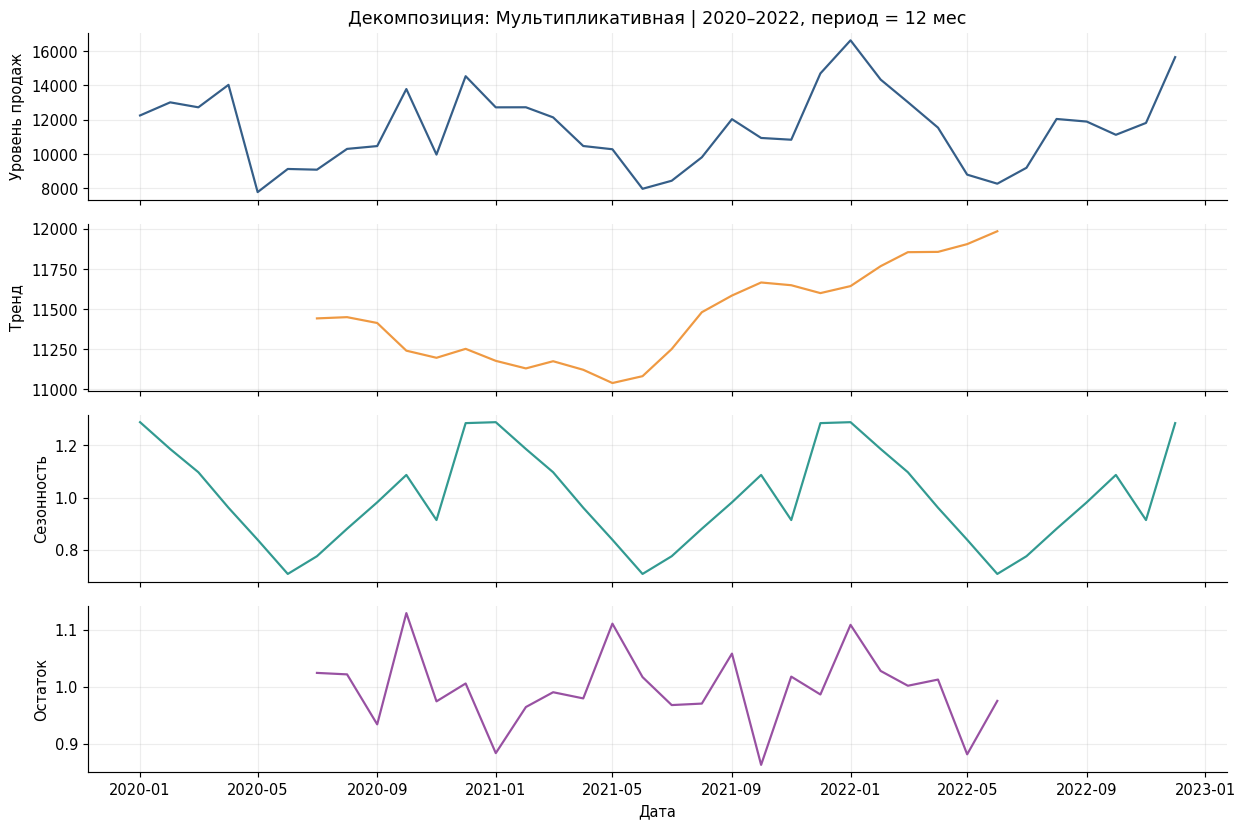

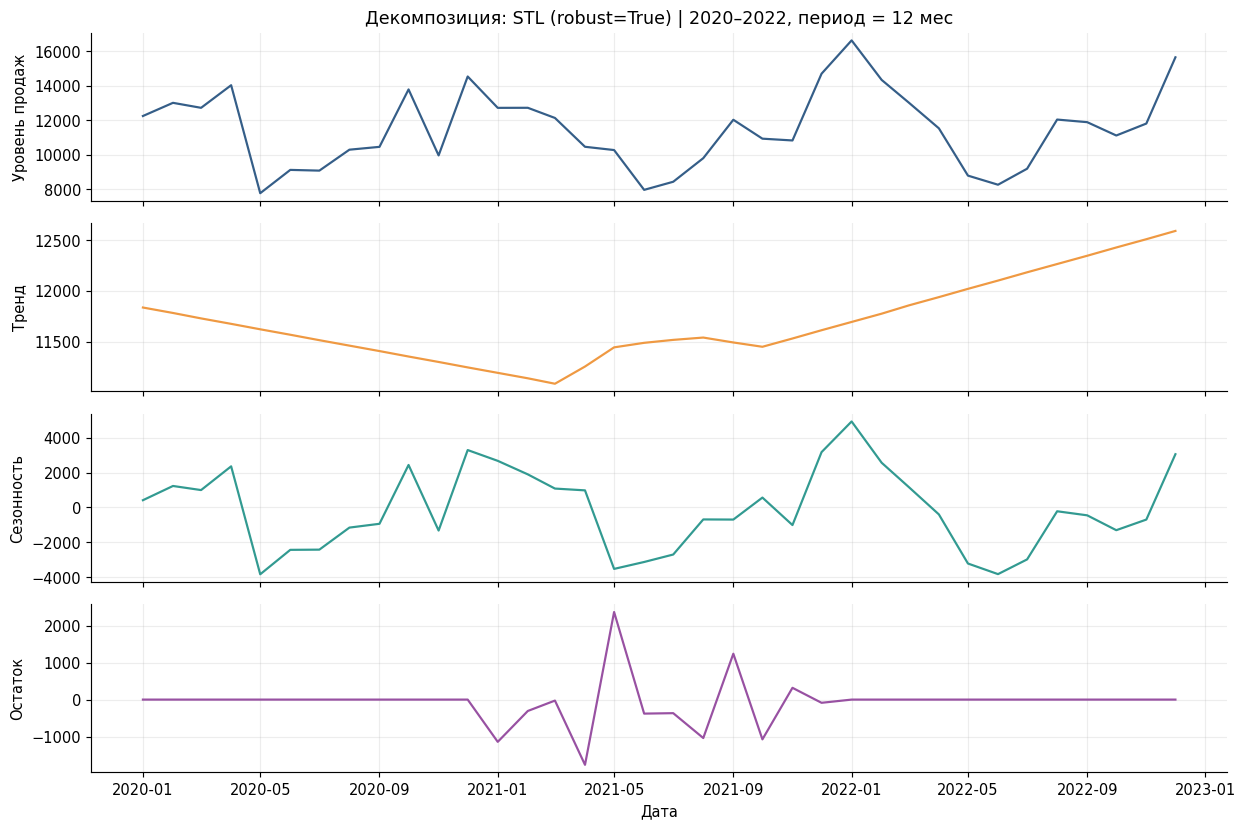

STL: сила сезонности F_s=0.920; сила тренда F_t=0.360 (в диапазоне от 0 до 1).
Амплитуда усреднённой STL-сезонности max-min: 6700 единиц продаж.
Диапазон мультипликативного сезонного индекса: 0.708…1.288; его 1.00 означает отсутствие сезонного отклонения.


In [39]:
PERIOD=12
add_dec=seasonal_decompose(history,model='additive',period=PERIOD,extrapolate_trend=0)
mul_dec=seasonal_decompose(history,model='multiplicative',period=PERIOD,extrapolate_trend=0)
stl_dec=STL(history,period=PERIOD,robust=True,seasonal=13).fit()

for name,res in [('Аддитивная',add_dec),('Мультипликативная',mul_dec),('STL (robust=True)',stl_dec)]:
    fig,axs=plt.subplots(4,1,figsize=(12,8),sharex=True)
    axs[0].plot(history,label='Исходные продажи',color='#355e88')
    axs[1].plot(res.trend,label='Тренд',color='#ef9942')
    axs[2].plot(res.seasonal,label='Сезонная компонента',color='#329a91')
    axs[3].plot(res.resid,label='Остаток',color='#9851a2')
    for a,ttl in zip(axs,['Уровень продаж','Тренд','Сезонность','Остаток']):
        a.set_ylabel(ttl)
    axs[0].set_title(f'Декомпозиция: {name} | 2020–2022, период = 12 мес')
    axs[-1].set_xlabel('Дата')
    plt.tight_layout()
    plt.show()


F_s=max(0.,1.-np.var(stl_dec.resid)/np.var(stl_dec.resid+stl_dec.seasonal))
F_t=max(0.,1.-np.var(stl_dec.resid)/np.var(stl_dec.resid+stl_dec.trend))
seasonal_climatology=stl_dec.seasonal.groupby(stl_dec.seasonal.index.month).mean()
print(f'STL: сила сезонности F_s={F_s:.3f}; сила тренда F_t={F_t:.3f} (в диапазоне от 0 до 1).')
print(f'Амплитуда усреднённой STL-сезонности max-min: '
      f'{seasonal_climatology.max()-seasonal_climatology.min():.0f} единиц продаж.')
print(f'Диапазон мультипликативного сезонного индекса: '
      f'{mul_dec.seasonal.min():.3f}…{mul_dec.seasonal.max():.3f}; '
      f'его 1.00 означает отсутствие сезонного отклонения.')

Сравнение трёх методов декомпозиции подтвердило наличие выраженной годовой сезонности в розничных продажах с периодом 12 месяцев. Наиболее высокие продажи наблюдаются зимой, минимальные - летом. STL-декомпозиция показала высокую силу сезонности (`F_s = 0,920`) при сравнительно слабом тренде (`F_t = 0,360`). Аддитивный и мультипликативный методы выявили схожую сезонную структуру, однако STL позволяет гибче оценивать её с учётом выбросов. Таким образом, сезонность является основным фактором изменения продаж, что обосновывает применение SARIMAX с годовым сезонным периодом 12 месяцев и сравнение её с обычной ARIMA.

### Спектральный анализ методом FFT

FFT переводит динамику в сумму гармоник; пик с частотой `f=1/12` циклов в месяц соответствует периоду 12 месяцев. Перед преобразованием убираем линейный тренд (`detrend`), поскольку низкие частоты иначе могут отражать тренд, а не сезонный цикл. Анализируем только ненулевые частоты и периоды примерно 2–24 месяца.

,"Период, мес.","Частота, цикл/мес.",Мощность,"Доля мощности, %"
0,12.000,0.083,1.936273e+09,60.563
1,2.000,0.500,1.951782e+08,6.105
2,6.000,0.167,1.823338e+08,5.703
3,4.000,0.250,1.662513e+08,5.200
4,3.600,0.278,1.509274e+08,4.721
5,2.118,0.472,1.433231e+08,4.483
6,3.000,0.333,9.604891e+07,3.004


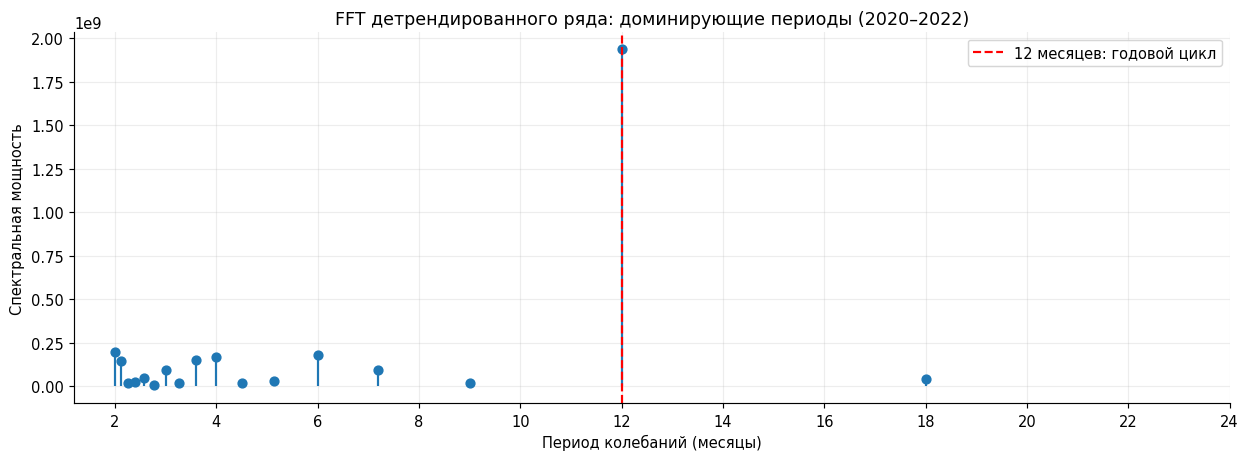

Вклад 12-месячной гармоники в мощность рассматриваемого спектра: 60.6%.
Самый мощный период: 12.0 мес. (60.6% рассмотренной мощности).


In [9]:
fft_signal=signal.detrend(history.to_numpy(),type='linear')
frequency=np.fft.rfftfreq(len(fft_signal),d=1.0)  # единица времени — месяц
fft_power=np.abs(np.fft.rfft(fft_signal))**2
mask=(frequency>0)&(1/frequency.clip(min=1e-12)>=2)&(1/frequency.clip(min=1e-12)<=24)
periods_fft=1/frequency[mask]
power_fft=fft_power[mask]
fft_table=(pd.DataFrame({'Период, мес.':periods_fft,'Частота, цикл/мес.':frequency[mask],
                         'Мощность':power_fft})
           .sort_values('Мощность',ascending=False).reset_index(drop=True))
fft_table['Доля мощности, %']=100*fft_table['Мощность']/fft_table['Мощность'].sum()
display(fft_table.head(7).round(3))

fig,ax=plt.subplots(figsize=(12,4.5))
ax.stem(periods_fft,power_fft,basefmt=' ')
ax.axvline(12,ls='--',color='red',label='12 месяцев: годовой цикл')
ax.set(xlabel='Период колебаний (месяцы)',ylabel='Спектральная мощность',
       title='FFT детрендированного ряда: доминирующие периоды (2020–2022)')
ax.set_xticks(np.arange(2,25,2));ax.legend();plt.tight_layout();plt.show()

closest12=int(np.argmin(abs(periods_fft-12)))
print(f'Вклад 12-месячной гармоники в мощность рассматриваемого спектра: '
      f'{100*power_fft[closest12]/power_fft.sum():.1f}%.')
print(f'Самый мощный период: {fft_table.loc[0,"Период, мес."]:.1f} мес. '
      f'({fft_table.loc[0,"Доля мощности, %"]:.1f}% рассмотренной мощности).')

### Вейвлет-анализ непрерывным преобразованием Морле

In [40]:
def morlet_cwt(values, periods, omega0=6.0):
    x=np.asarray(values,dtype=float)
    x=x-x.mean()
    coefficients=np.empty((len(periods),len(x)),dtype=complex)
    for i,period in enumerate(periods):
        scale=float(period)*omega0/(2*np.pi)
        # +-4sigma гауссовой огибающей: практически вся энергия в окне.
        extent=int(np.ceil(4*scale))
        u=np.arange(-extent,extent+1)/scale
        wave=np.exp(1j*omega0*u)*np.exp(-0.5*u*u)
        wave/=np.sqrt(scale)
        coefficients[i]=fftconvolve(x,np.conj(wave[::-1]),mode='same')
    return coefficients

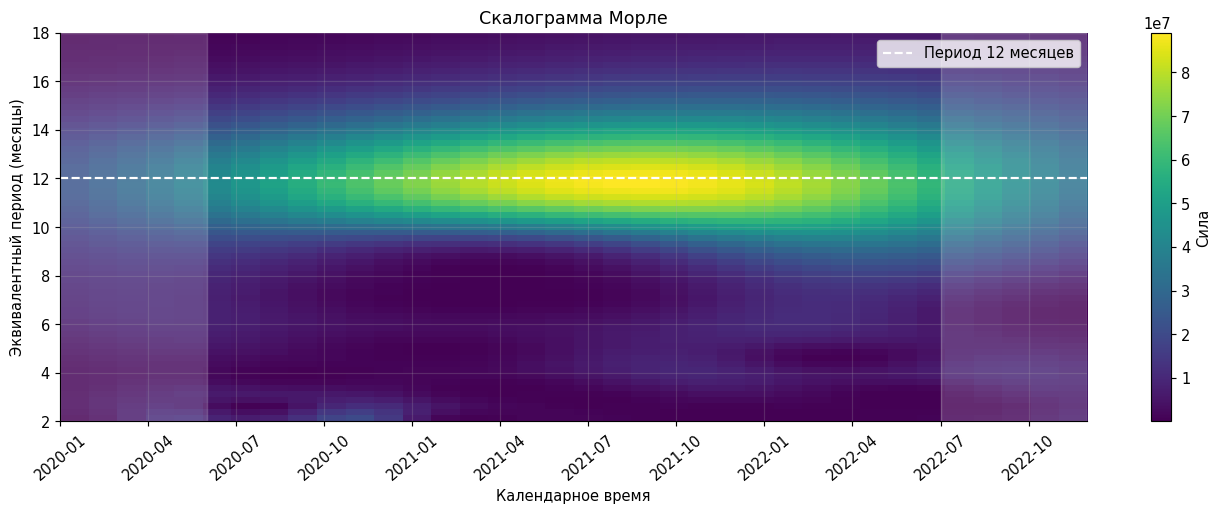

In [ ]:
cwt_periods=np.linspace(2,18,65)
cwt=morlet_cwt(signal.detrend(history.to_numpy()),cwt_periods)
cwt_power=np.abs(cwt)**2
mean_power=cwt_power.mean(axis=1)
strongest_cwt=float(cwt_periods[np.argmax(mean_power)])

fig,ax=plt.subplots(figsize=(13,5))
im=ax.imshow(cwt_power,aspect='auto',origin='lower',cmap='viridis',
             extent=[0,len(history)-1,cwt_periods.min(),cwt_periods.max()])
ax.axhline(12,color='white',linestyle='--',linewidth=1.5,label='Период 12 месяцев')
ax.axvspan(0,5,alpha=0.17,color='white')
ax.axvspan(len(history)-6,len(history)-1,alpha=0.17,color='white')
ax.set(xticks=np.arange(0,len(history),3),xticklabels=[history.index[i].strftime('%Y-%m')
      for i in range(0,len(history),3)],xlabel='Календарное время',
      ylabel='Эквивалентный период (месяцы)',title='Спектрограмма Морле')
ax.tick_params(axis='x',rotation=40)
ax.legend(loc='upper right');fig.colorbar(im,ax=ax,label='Мощность колебаний')

plt.tight_layout()
plt.show()

Вейвлет-анализ Морле выявил выраженную концентрацию мощности колебаний вблизи периода 12 месяцев, что подтверждает наличие годовой сезонной составляющей, ранее обнаруженной при декомпозиции временного ряда.
В отличие от FFT, вейвлет-преобразование позволяет анализировать распределение мощности колебаний во времени. Однако из-за небольшой длины ряда и краевых эффектов изменение интенсивности сезонности во времени нельзя оценить с высокой уверенностью

Таким образом, вейвлет-анализ дополнительно подтверждает целесообразность применения сезонной модели SARIMAX с периодом 12

### Сопоставление результатов трёх подходов

| Метод | Что обнаруживает | Преимущества | Ограничения | Результат для ряда |
|---|---|---|---|---|
| Классическая аддитивная декомпозиция | Тренд и повторяющийся годовой сезонный профиль | Простая интерпретация сезонных колебаний в абсолютных единицах продаж | Фиксированная сезонность; потеря краевых значений тренда | Выявлены выраженные абсолютные сезонные колебания |
| Классическая мультипликативная декомпозиция | Сезонность в относительных коэффициентах | Позволяет оценить влияние сезонности в процентах от уровня продаж | Требует положительных значений; сезонность фиксирована | Сезонный индекс: 0,708–1,288 (от −29,2% до +28,8%) |
| STL | Тренд, годовую сезонность и локальные остаточные колебания | Гибкое сглаживание, относительная устойчивость к выбросам | Чувствительность к параметрам сглаживания и короткой истории | Сила сезонности **0,920**, сила тренда **0,360** |
| FFT | Доминирующие частоты за весь период наблюдения | Количественное определение основных периодов | Не показывает изменение периодичности во времени; спектральная утечка | Доминирующий период — **12,0 месяца** |
| Вейвлет Морле | Периодичность колебаний и её распределение во времени | Позволяет оценить локализацию сезонных колебаний | Краевые эффекты, зависимость от масштаба и ограниченной длины ряда | Максимум средней мощности — около **11,8 месяца** |

Общий результат сравнения: все рассмотренные методы указывают на выраженную годовую сезонность розничных продаж. Классические методы позволяют интерпретировать сезонные изменения, STL количественно оценивает их выраженность, FFT определяет доминирующий период, а CWT показывает распределение мощности сезонных колебаний во времени

Полученные результаты обосновывают необходимость сравнения несезонной ARIMA с моделями SARIMAX, учитывающими 12-месячный цикл

## 1.3 Выводы


- Для разведочного анализа использованы **36 ежемесячных наблюдений за 2020–2022 годы**. Полный набор данных содержит **48 наблюдений за 2020–2023 годы**.
Временной ряд имеет непрерывную месячную частоту. Пропущенные значения и дубликаты дат отсутствуют, все значения продаж строго положительны

- Средний объём продаж составляет **11 512 единиц**, стандартное отклонение - **2 233 единицы**, коэффициент вариации - **19.4%**.
Это свидетельствует о заметной изменчивости уровня продаж. Следовательно, модель, прогнозирующая только постоянное среднее значение, может не учитывать существенные закономерности временного ряда

- Анализ средних продаж по месяцам: **максимальные средние продажи** - в декабре, **минимальные** - в июне, относительный размах между максимальным и минимальным среднемесячными значениями составляет **76,8%** от минимума. Выраженные сезонные изменения необходимо учитывать при прогнозировании спроса и планировании товарных запасов

- За исследуемые 36 месяцев рекламные акции проводились в 5 месяцах. Сравнение средних продаж в периоды с акциями и без них носит наблюдательный характер и не позволяет установить причинно-следственную связь. Поскольку будущие рекламные акции заранее неизвестны, их фактические значения не должны использоваться при прогнозировании во избежание утечки данных

- Классическая аддитивная, мультипликативная и STL-декомпозиция подтвердили наличие годовой сезонности. По результатам STL-декомпозиции сезонная составляющая выражена значительно сильнее трендовой

- Быстрое преобразование Фурье (FFT) выявило доминирующий период колебаний продолжительностью **12,0 месяца**. Вейвлет-анализ Морле (CWT) показал максимальную среднюю мощность колебаний около периода **11,8 месяца**

- Основным ограничением является небольшой объём исторических данных - всего три полных годовых сезонных цикла

На основании проведённого анализа целесообразно сравнить следующие подходы:

1. ARIMA - несезонная модель, используемая в качестве базового ориентира
2. SARIMAX с сезонным периодом s = 12 - модель, учитывающая годовую сезонную структуру
3. SARIMAX с гармониками Фурье - компактная модель с календарными гармониками периодов 12 и 6 месяцев и известным декабрьским индикатором

---
# 2. Построение и обоснование прогнозных моделей

## 2.1 Матрица известных календарных признаков

- Гармоники вычисляются только из даты 
- Сочетание первой и второй гармоник описывает асимметричный годовой профиль с летним минимумом и зимним максимумом
- Декабрь дополнительно характеризуется индикатором `HolidayMonth`

In [46]:
# Дизайн-матрица строится только по дате; одинаковые формулы используем на всех этапах.
BASE_DATE=df.index.min()
def calendar_features(index):
    index=pd.DatetimeIndex(index)
    t=np.asarray((index.year-BASE_DATE.year)*12+(index.month-BASE_DATE.month),dtype=float)
    data={}
    for k in (1,2):
        data[f'sin{k}']=np.sin(2*np.pi*k*t/12)
        data[f'cos{k}']=np.cos(2*np.pi*k*t/12)
    data['HolidayMonth']=(index.month==12).astype(float)
    return pd.DataFrame(data,index=index)

X=calendar_features(df.index)
assert np.array_equal(X['HolidayMonth'].astype(int).values,df['HolidayMonth'].astype(int).values)
FOURIER_COLS=['sin1','cos1','sin2','cos2']
CALENDAR_COLS=FOURIER_COLS+['HolidayMonth']

print('Матрица признаков:',list(X.columns))
display(X.head(13).round(3))

Матрица признаков: ['sin1', 'cos1', 'sin2', 'cos2', 'HolidayMonth']


,sin1,cos1,sin2,cos2,HolidayMonth
Date,,,,,
2020-01-01,0.000,1.000,0.000,1.0,0.0
2020-02-01,0.500,0.866,0.866,0.5,0.0
2020-03-01,0.866,0.500,0.866,-0.5,0.0
2020-04-01,1.000,0.000,0.000,-1.0,0.0
2020-05-01,0.866,-0.500,-0.866,-0.5,0.0
2020-06-01,0.500,-0.866,-0.866,0.5,0.0
2020-07-01,0.000,-1.000,-0.000,1.0,0.0
2020-08-01,-0.500,-0.866,0.866,0.5,0.0
2020-09-01,-0.866,-0.500,0.866,-0.5,0.0


## 2.2 Обучение кандидатов и сравнение на валидации

Для симметрии базового эксперимента используем одни и те же 24 обучающих и 12 валидационных месяцев для всех моделей. 

В таблице:
- MSE, R2 и WAPE - прогнозные показатели на 2022 году
- AIC и BIC - показатели подгонки на 2020-2021 годах

Единый словарь конфигураций:

In [47]:
MODEL_CONFIGS={
    'ARIMA(0,0,0)':       {'family':'ARIMA','order':(0,0,0)},
    'ARIMA(1,0,0)':       {'family':'ARIMA','order':(1,0,0)},
    'ARIMA(2,0,0)':       {'family':'ARIMA','order':(2,0,0)},
    'ARIMA(1,0,1)':       {'family':'ARIMA','order':(1,0,1)},
    'ARIMA(2,0,1)':       {'family':'ARIMA','order':(2,0,1)},
    'ARIMA(1,1,0)':       {'family':'ARIMA','order':(1,1,0)},
    'ARIMA(0,1,1)':       {'family':'ARIMA','order':(0,1,1)},
    'SARIMAX (0,0,0)x(0,1,0,12)':{'family':'SARIMAX','order':(0,0,0),
                                  'seasonal_order':(0,1,0,12),'exog':None},
    'SARIMAX (1,0,0)x(0,1,0,12)':{'family':'SARIMAX','order':(1,0,0),
                                  'seasonal_order':(0,1,0,12),'exog':None},
    'SARIMAX (0,1,1)x(0,1,0,12)':{'family':'SARIMAX','order':(0,1,1),
                                  'seasonal_order':(0,1,0,12),'exog':None},
    'SARIMAX Фурье (K=2)':{'family':'SARIMAX','order':(0,0,0),
                            'seasonal_order':(0,0,0,12),'exog':FOURIER_COLS},
    'SARIMAX Фурье + декабрь':{'family':'SARIMAX','order':(0,0,0),
                                'seasonal_order':(0,0,0,12),'exog':CALENDAR_COLS},
}

In [48]:
def fit_named(name,target, maxiter=200):
    cfg=MODEL_CONFIGS[name]
    order=cfg['order']
    if cfg['family']=='ARIMA':
        trend='c' if order[1]==0 else 'n'
        return ARIMA(target,order=order,trend=trend,
                     enforce_stationarity=False,enforce_invertibility=False).fit(
                         method_kwargs={'maxiter':maxiter})
    seas=cfg['seasonal_order']
    trend='c' if order[1]==0 and seas[1]==0 else 'n'
    exog=calendar_features(target.index)[cfg['exog']] if cfg['exog'] else None
    return SARIMAX(target,exog=exog,order=order,seasonal_order=seas,
                   trend=trend,enforce_stationarity=False,
                   enforce_invertibility=False).fit(disp=False,maxiter=maxiter)

In [49]:
def forecast_named(name,fitted,dates):
    cfg=MODEL_CONFIGS[name]
    future_exog=calendar_features(dates)[cfg['exog']] if cfg.get('exog') else None
    f=fitted.get_forecast(steps=len(dates),exog=future_exog)
    prediction=pd.Series(np.asarray(f.predicted_mean),index=dates,name=name)
    interval=f.conf_int(alpha=0.05)
    interval=pd.DataFrame(np.asarray(interval),index=dates,columns=['Нижняя 95%','Верхняя 95%'])
    return prediction,interval

In [51]:
def evaluation(actual,predicted):
    a=np.asarray(actual,dtype=float)
    p=np.asarray(predicted,dtype=float)
    return {'MSE':mean_squared_error(a,p),'RMSE':np.sqrt(mean_squared_error(a,p)),
            'MAE':mean_absolute_error(a,p),'R2':r2_score(a,p) if len(a)>=2 else np.nan,
            'WAPE, %':100*np.sum(np.abs(a-p))/np.sum(np.abs(a)),
            'sMAPE, %':100*np.mean(2*np.abs(a-p)/(np.abs(a)+np.abs(p)))}

In [52]:
validation_rows=[]
validation_models={}
validation_preds={}
for name,cfg in MODEL_CONFIGS.items():
    try:
        fitted=fit_named(name,train)
        pred,_=forecast_named(name,fitted,valid.index)
        # Не считаем нефинитные показатели и предупреждаем о несходимости.
        ev=evaluation(valid,pred)
        ok=bool(fitted.mle_retvals.get('converged',True)) if hasattr(fitted,'mle_retvals') else True
        if not np.isfinite([ev['MSE'],fitted.aic]).all():
            raise ValueError('Нефинитное MSE или AIC')
        validation_models[name]=fitted
        validation_preds[name]=pred
        validation_rows.append({'Модель':name,'Семейство':cfg['family'],
                                'AIC train':fitted.aic,'BIC train':fitted.bic,
                                **ev,'Сходимость':ok})
    except Exception as exc:
        print(f'Исключён кандидат {name}: {type(exc).__name__}: {str(exc)[:100]}')
val_results=pd.DataFrame(validation_rows).sort_values('MSE').reset_index(drop=True)
assert {'SARIMAX Фурье (K=2)','SARIMAX Фурье + декабрь'}.issubset(validation_models)
assert any(val_results['Семейство']=='ARIMA')
display(val_results.round({'MSE':0,'RMSE':1,'MAE':1,'R2':3,'WAPE, %':2,'sMAPE, %':2,
                           'AIC train':2,'BIC train':2}))

,Модель,Семейство,AIC train,BIC train,MSE,RMSE,MAE,R2,"WAPE, %","sMAPE, %",Сходимость
0,SARIMAX Фурье (K=2),SARIMAX,404.61,411.42,2297711.0,1515.8,1112.7,0.628,9.25,8.93,True
1,"SARIMAX (0,0,0)x(0,1,0,12)",SARIMAX,197.17,197.56,2458517.0,1568.0,1207.0,0.602,10.04,10.10,True
2,"SARIMAX (1,0,0)x(0,1,0,12)",SARIMAX,196.11,196.90,2500312.0,1581.2,1210.6,0.595,10.07,10.12,True
3,SARIMAX Фурье + декабрь,SARIMAX,395.48,403.43,2556102.0,1598.8,995.4,0.586,8.28,7.93,True
4,"SARIMAX (0,1,1)x(0,1,0,12)",SARIMAX,170.03,170.42,2568520.0,1602.7,1245.0,0.584,10.35,10.45,True
5,"ARIMA(2,0,1)",ARIMA,404.74,410.19,5643327.0,2375.6,1863.1,0.087,15.49,15.64,True
6,"ARIMA(1,0,0)",ARIMA,419.48,422.89,5719067.0,2391.5,1913.5,0.075,15.91,16.07,True
7,"ARIMA(1,0,1)",ARIMA,403.69,408.05,5758336.0,2399.7,1904.8,0.068,15.84,15.99,True
8,"ARIMA(2,0,0)",ARIMA,403.19,407.56,5809755.0,2410.3,1881.9,0.060,15.65,15.79,True
9,"ARIMA(0,0,0)",ARIMA,419.56,421.83,6841471.0,2615.6,2055.7,-0.107,17.09,17.27,True


1. Лучшая ARIMA: `ARIMA(2,0,1)`
2. Выбранная SARIMAX: `SARIMAX Фурье + декабрь` (тк Декабрь улучшает AIC при допустимой потере точности валидации относительно Фурье-базы)
3. Отношение MSE (Фурье+декабрь)/(Фурье): 1.112
4. Выбранная модель на ВАЛИДАЦИИ: MSE=2,556,057, R2=0.586, WAPE=8.3%

Объективное визуальное сопоставление прогнозов одного года (2022)

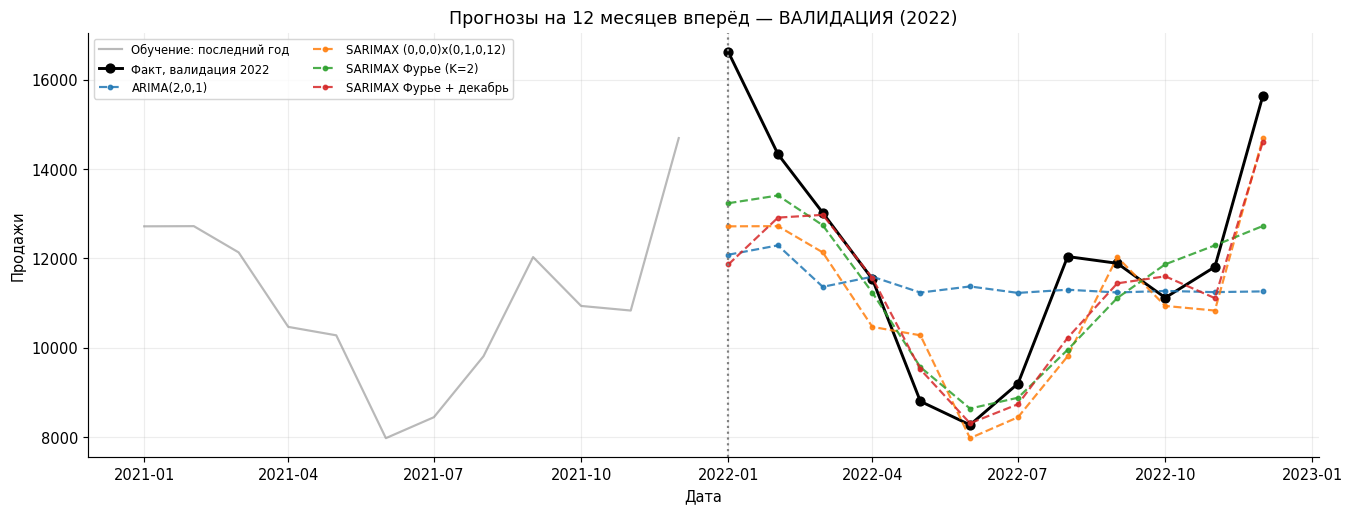

In [55]:
fig,ax=plt.subplots(figsize=(13,5))
ax.plot(train.iloc[-12:],color='gray',alpha=.55,label='Обучение: последний год')
ax.plot(valid,marker='o',color='black',lw=2,label='Факт, валидация 2022')
for name in list(dict.fromkeys(['ARIMA(2,0,1)','SARIMAX (0,0,0)x(0,1,0,12)',
                                'SARIMAX Фурье (K=2)','SARIMAX Фурье + декабрь'])):
    if name in validation_preds:
        ax.plot(validation_preds[name],ls='--',marker='.',alpha=.85,label=name)
ax.axvline(valid.index.min(),ls=':',color='gray')
ax.set(title='Прогнозы на 12 месяцев вперёд — ВАЛИДАЦИЯ (2022)',
       ylabel='Продажи',xlabel='Дата')
ax.legend(fontsize=8,ncol=2)

plt.tight_layout()
plt.show()

## 2.3 Выводы

1. Сравнено 12 кандидатов на одном отрезке обучения из 24 месяцев с единым прогнозным горизонтом 12 месяцев (валидация 2022)
2. Лучшая ARIMA на валидации - `ARIMA(2,0,1)`: MSE=5,643,327, R2=0.087, WAPE=15.5%.
3. SARIMAX c годовой сезонной разностью - прозрачная реализация сезонного переноса прошлого года: MSE=2,458,517, R2=0.602.
4. Зафиксированная финальная спецификация - `SARIMAX Фурье + декабрь`: MSE=2,556,057, R2=0.586, WAPE=8.3% (декабрь улучшает AIC при допустимой потере точности валидации относительно Фурье-базы)
5. Следующий этап - переобучение только на 2020–2022 и проверка отложенного 2023 года

---
# 3. Качество прогноза и диагностика остатков

## 3.1 контрольный тест на 2023 год

In [65]:
test_model_names=list(dict.fromkeys([
    'ARIMA(2,0,1)','SARIMAX (0,0,0)x(0,1,0,12)','SARIMAX (0,1,1)x(0,1,0,12)','SARIMAX Фурье (K=2)','SARIMAX Фурье + декабрь','SARIMAX Фурье + декабрь'
]))
test_fits={};test_predictions={};test_intervals={};test_rows=[]
for name in test_model_names:
    fitted=fit_named(name,history)
    pred,ci=forecast_named(name,fitted,test.index)
    test_fits[name]=fitted
    test_predictions[name]=pred
    test_intervals[name]=ci
    test_rows.append({'Модель':name,'Приоритетный вариант':name=='SARIMAX Фурье + декабрь',
                      'AIC train+val':fitted.aic,'BIC train+val':fitted.bic,
                      **evaluation(test,pred)})

test_results=pd.DataFrame(test_rows).sort_values('MSE').reset_index(drop=True)
display(test_results.round({'MSE':0,'RMSE':1,'MAE':1,'R2':3,'WAPE, %':2,'sMAPE, %':2,
                            'AIC train+val':2,'BIC train+val':2}))

chosen_metrics=test_results.set_index('Модель').loc['SARIMAX Фурье + декабрь']
base_metrics=test_results.set_index('Модель').loc['SARIMAX (0,0,0)x(0,1,0,12)']
arima_metrics=test_results.set_index('Модель').loc['ARIMA(2,0,1)']

,Модель,Приоритетный вариант,AIC train+val,BIC train+val,MSE,RMSE,MAE,R2,"WAPE, %","sMAPE, %"
0,SARIMAX Фурье + декабрь,True,603.41,614.30,2259099.0,1503.0,1002.9,0.512,8.00,8.34
1,"SARIMAX (0,1,1)x(0,1,0,12)",False,382.68,384.77,2546563.0,1595.8,1101.1,0.449,8.78,8.28
2,"SARIMAX (0,0,0)x(0,1,0,12)",False,407.90,409.04,2757115.0,1660.5,1147.6,0.404,9.15,9.31
3,SARIMAX Фурье (K=2),False,610.51,619.84,3283931.0,1812.2,1210.8,0.290,9.66,9.80
4,"ARIMA(2,0,1)",False,616.52,624.15,5509336.0,2347.2,1561.0,-0.191,12.45,12.56


- Заранее выбранная модель: `SARIMAX Фурье + декабрь`
- Тест 2023: MSE=2,259,099, RMSE=1,503, R2=0.512, WAPE=8.0%
- Снижение MSE относительно лучшей ARIMA: +59.0%; относительно сезонного переноса года: +18.1%

## 3.2 Графики прогноза и фактических ошибок

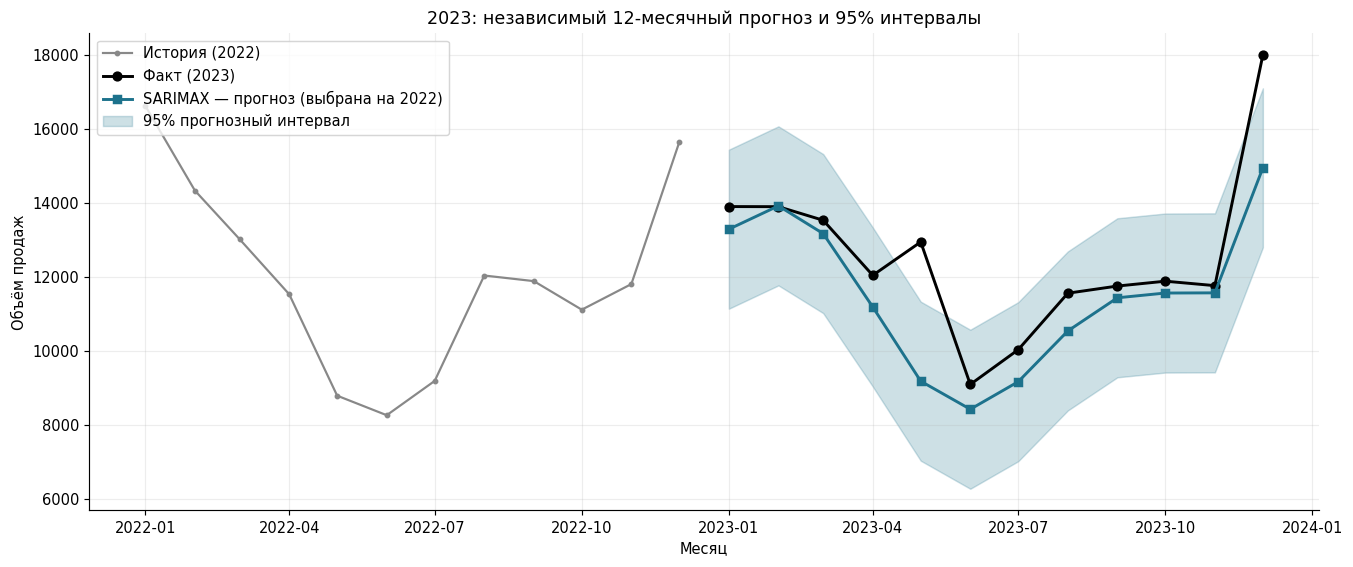

,Факт,Прогноз,Ошибка (факт − прогноз),"Абс. ошибка, %",Внутри 95% интервала
Date,,,,,
2023-01-01,13904.0,13293.41,610.59,4.39,True
2023-02-01,13901.0,13922.68,-21.68,0.16,True
2023-03-01,13534.0,13173.99,360.01,2.66,True
2023-04-01,12048.0,11194.28,853.72,7.09,True
2023-05-01,12949.0,9191.64,3757.36,29.02,False
2023-06-01,9104.0,8433.98,670.02,7.36,True
2023-07-01,10042.0,9178.01,863.99,8.60,True
2023-08-01,11566.0,10546.74,1019.26,8.81,True
2023-09-01,11759.0,11442.10,316.90,2.69,True


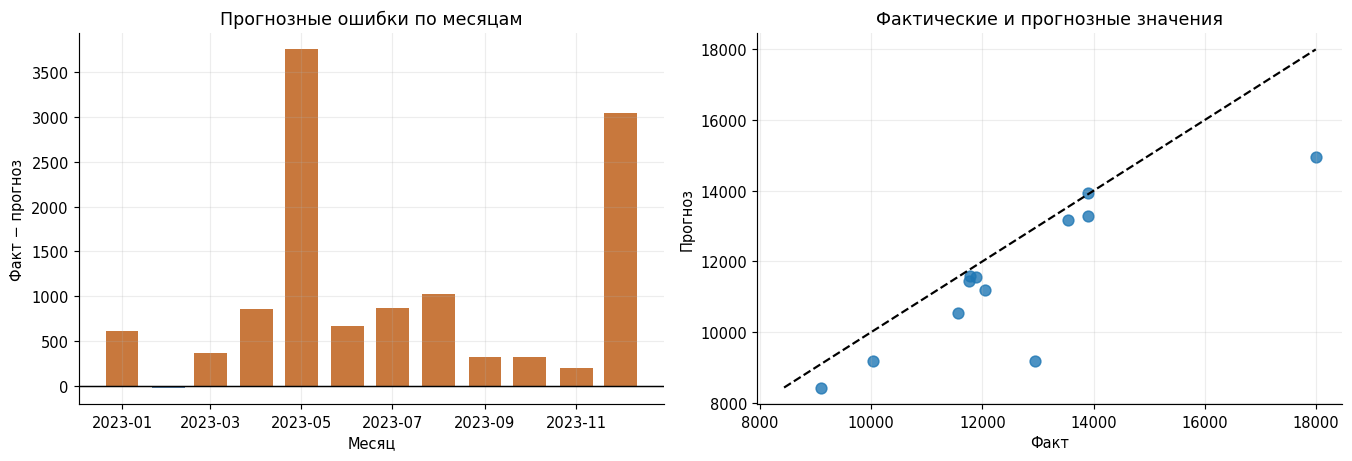

Покрытие 95%-го интервала: 10 / 12 = 83.3%.
Наибольшая относительная ошибка: 2023-05 — 29.0% (акция: 1).


In [66]:
forecast=test_predictions['SARIMAX Фурье + декабрь']
conf_int=test_intervals['SARIMAX Фурье + декабрь']
within=(test.values>=conf_int['Нижняя 95%'].values)&(test.values<=conf_int['Верхняя 95%'].values)
coverage=float(within.mean())

fig,ax=plt.subplots(figsize=(13,5.5))
ax.plot(history.iloc[-12:],color='#888888',marker='.',label='История (2022)')
ax.plot(test,color='black',marker='o',lw=2,label='Факт (2023)')
ax.plot(forecast,color='#1d728c',lw=2,marker='s',label='SARIMAX — прогноз (выбрана на 2022)')
ax.fill_between(test.index,conf_int['Нижняя 95%'].values,conf_int['Верхняя 95%'].values,
                alpha=.22,color='#1d728c',label='95% прогнозный интервал')
ax.set(title='2023: независимый 12-месячный прогноз и 95% интервалы',
       xlabel='Месяц',ylabel='Объём продаж')
ax.legend(loc='upper left');plt.tight_layout();plt.show()

errors=(test-forecast).rename('Факт − прогноз')
monthly_error=pd.DataFrame({'Факт':test,'Прогноз':forecast,
                            'Ошибка (факт − прогноз)':errors,
                            'Абс. ошибка, %':100*errors.abs()/test,
                            'Внутри 95% интервала':within})
display(monthly_error.round(2))

fig,axs=plt.subplots(1,2,figsize=(13,4.5))
axs[0].bar(test.index,errors,color=np.where(errors>=0,'#c8783d','#5982a9'),width=22)
axs[0].axhline(0,color='black',lw=1)
axs[0].set(title='Прогнозные ошибки по месяцам',xlabel='Месяц',ylabel='Факт − прогноз')
axs[1].scatter(test.values,forecast.values,s=55,alpha=.8)
mmin=min(test.min(),forecast.min());mmax=max(test.max(),forecast.max())
axs[1].plot([mmin,mmax],[mmin,mmax],color='black',ls='--')
axs[1].set(title='Фактические и прогнозные значения',xlabel='Факт',ylabel='Прогноз')
plt.tight_layout();plt.show()

max_err_m=monthly_error['Абс. ошибка, %'].idxmax()
print(f'Покрытие 95%-го интервала: {int(within.sum())} / {len(within)} = {coverage*100:.1f}%.')
print(f'Наибольшая относительная ошибка: {max_err_m:%Y-%m} — '
      f'{monthly_error.loc[max_err_m,"Абс. ошибка, %"]:.1f}% (акция: '
      f'{int(df.loc[max_err_m,"Promotion"])}).')

- Первый график показывает качество 12-шагового прогноза и 95%-й модельный предиктивный интервал - 10 / 12 = `83.3%`
- Последний зависит от предпосылок модели (в том числе распределения и устойчивости ошибок), поэтому его фактическое покрытие контролируем отдельно
- График по месяцам: хорошее среднее качество может скрывать существенные недопрогнозы отдельных акционных или праздничных месяцев
- Наибольшая относительная ошибка: 2023-05 — 29.0% (акция: 1)

## 3.3. AIC / BIC: корректная область применения

Сопоставимый информационный критерий: две модели с одинаковой сезонной параметризацией (0,0,0)x(0,0,0), разница - дополнительный календарный индикатор

,Модель,AIC,BIC,Число оцениваемых параметров
0,SARIMAX Фурье (K=2),610.51,619.84,6
1,SARIMAX Фурье + декабрь,603.41,614.30,7


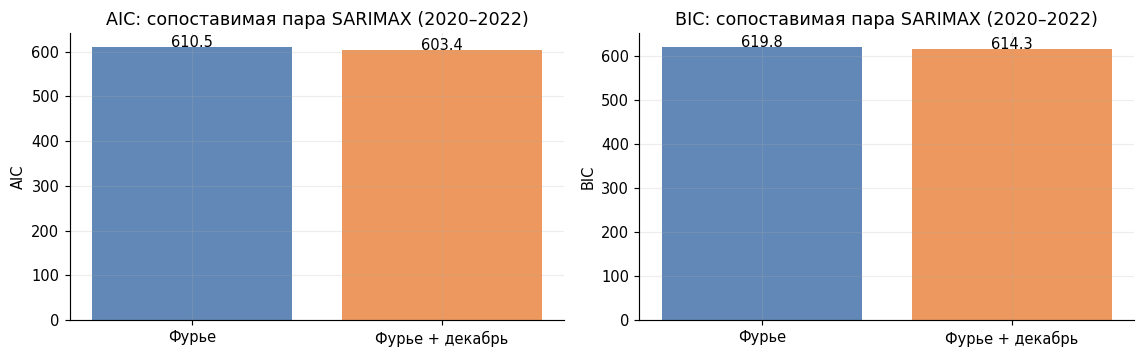

При добавлении декабрьского признака AIC изменился на -7.09, BIC — на -5.54.


In [ ]:
aic_pair=pd.DataFrame([
    {'Модель':nm,'AIC':test_fits[nm].aic,'BIC':test_fits[nm].bic,
     'Число оцениваемых параметров':len(test_fits[nm].params)}
    for nm in ['SARIMAX Фурье (K=2)','SARIMAX Фурье + декабрь']
])
display(aic_pair.round(2))

fig,axs=plt.subplots(1,2,figsize=(11,3.5))
for a,c in zip(axs,['AIC','BIC']):
    a.bar(['Фурье','Фурье + декабрь'],aic_pair[c],color=['#6188b7','#ed985e'])
    a.set(title=f'{c}: сопоставимая пара SARIMAX (2020–2022)',ylabel=c)
    for i,v in enumerate(aic_pair[c]):a.text(i,v+0.6,f'{v:.1f}',ha='center')
plt.tight_layout()
plt.show()

print(f'При добавлении декабрьского признака AIC изменился на '
      f'{aic_pair.loc[1,"AIC"]-aic_pair.loc[0,"AIC"]:+.2f}, '
      f'BIC — на {aic_pair.loc[1,"BIC"]-aic_pair.loc[0,"BIC"]:+.2f}.')

## 3.4. Диагностика обучающих остатков

Идеальный остаток должен быть близок к белому шуму: без значимых корреляций и без заметно меняющейся дисперсии

In [70]:
def residual_diagnostics(name,model):
    res=pd.Series(np.asarray(model.resid),index=model.model.data.row_labels,dtype=float)
    sea=MODEL_CONFIGS[name].get('seasonal_order',(0,0,0,0))
    burn=max(int(getattr(model,'loglikelihood_burn',0)),
             12 if sea[1]>0 else 0)
    res=res.iloc[burn:].replace([np.inf,-np.inf],np.nan).dropna()
    fitted=pd.Series(np.asarray(model.fittedvalues),index=model.model.data.row_labels).loc[res.index]
    X_bp=sm.add_constant(np.column_stack([fitted.values,np.arange(len(res))]))
    sh=stats.shapiro(res).pvalue if len(res)>=3 else np.nan
    lb=acorr_ljungbox(res,lags=[6,12] if len(res)>14 else [6],return_df=True)
    bp=het_breuschpagan(res,X_bp)[1]
    arch=het_arch(res,nlags=min(6,len(res)//4))[1]
    return {'Модель':name,'n остатков':len(res),'p Shapiro':sh,
            'p Ljung–Box(6)':lb.loc[6,'lb_pvalue'],
            'p Ljung–Box(12)':lb.loc[12,'lb_pvalue'] if 12 in lb.index else np.nan,
            'p Breusch–Pagan':bp,'p ARCH LM':arch,'Средний остаток':res.mean()},res,fitted

c:\Users\schepa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
c:\Users\schepa\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\stats\diagnostic.py:997: FutureWarning: acorr_lm currently returns a plain tuple whose length depends on the store argument. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an LMTestResult NamedTuple. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  return acorr_lm(
c:\Users\schepa\AppData\Local\Prog

,Модель,n остатков,p Shapiro,p Ljung–Box(6),p Ljung–Box(12),p Breusch–Pagan,p ARCH LM,Средний остаток
0,"ARIMA(2,0,1)",34,0.7705,0.5183,0.4443,0.1413,0.1565,-362.6759
1,"SARIMAX (0,0,0)x(0,1,0,12)",23,0.7773,0.5860,0.7014,0.2745,0.8444,294.1304
2,SARIMAX Фурье + декабрь,35,0.0014,0.5841,0.7454,0.4681,0.8977,1.6654


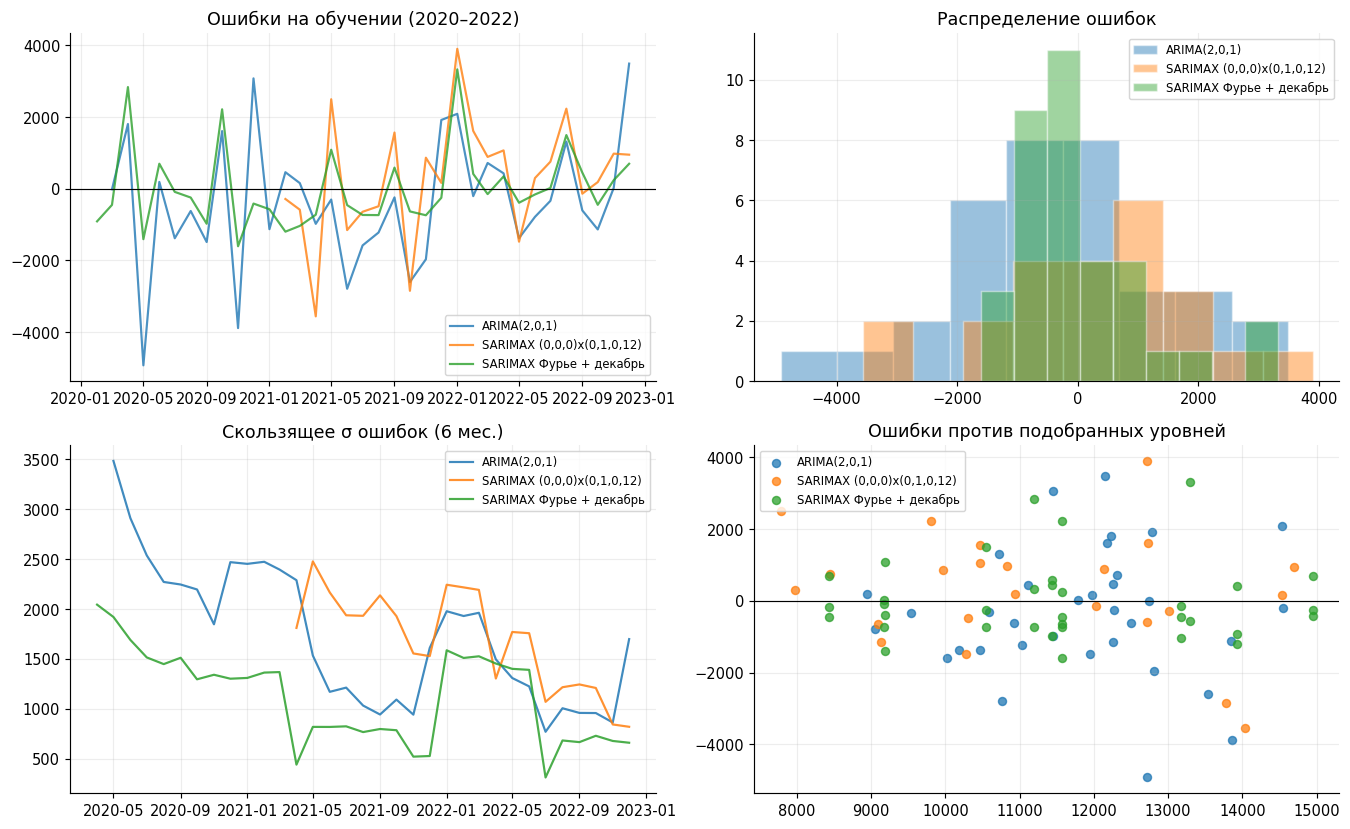

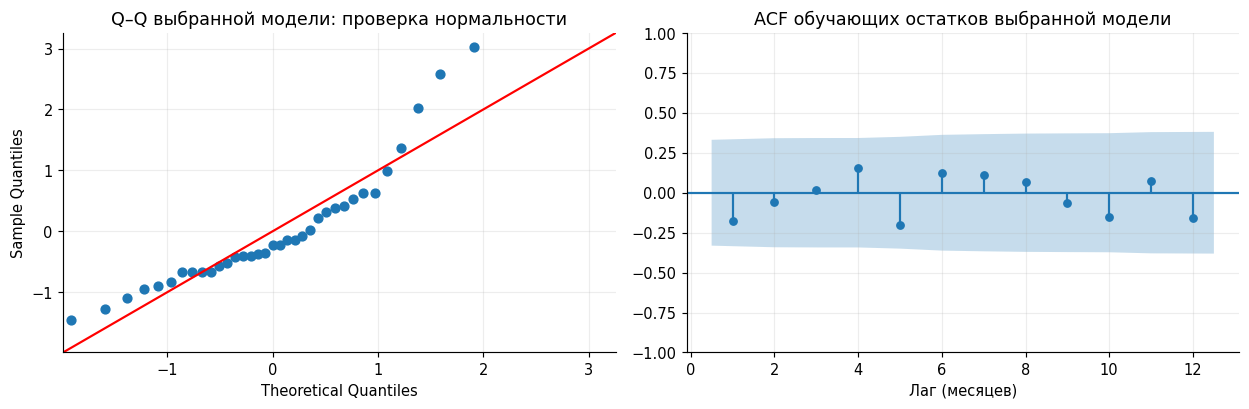

нормальность: p=0.0014 → H0 отклоняется при 5%
отсутствие автокорреляции до 12: p=0.7454 → нет оснований отклонить H0
гомоскедастичность: p=0.4681 → нет оснований отклонить H0
отсутствие ARCH: p=0.8977 → нет оснований отклонить H0


In [69]:
diag_names=list(dict.fromkeys(['ARIMA(2,0,1)','SARIMAX (0,0,0)x(0,1,0,12)','SARIMAX Фурье + декабрь']))
diag=[];residual_objects={}
for nm in diag_names:
    r,rs,fp=residual_diagnostics(nm,test_fits[nm])
    diag.append(r);residual_objects[nm]=(rs,fp)
diag_table=pd.DataFrame(diag)
display(diag_table.round(4))

fig,axs=plt.subplots(2,2,figsize=(13,8))
for nm,(rs,fp) in residual_objects.items():
    axs[0,0].plot(rs.index,rs.values,label=nm,alpha=.8)
    axs[0,1].hist(rs,bins=9,alpha=.45,label=nm,edgecolor='white')
    axs[1,0].plot(rs.index,rs.rolling(6,min_periods=3).std(),label=nm,alpha=.85)
    axs[1,1].scatter(fp.values,rs.values,label=nm,alpha=.75,s=30)
axs[0,0].axhline(0,color='black',lw=.8)
axs[1,1].axhline(0,color='black',lw=.8)
for a,ttl in zip(axs.ravel(),['Ошибки на обучении (2020–2022)','Распределение ошибок',
                              'Скользящее σ ошибок (6 мес.)','Ошибки против подобранных уровней']):
    a.set_title(ttl);a.legend(fontsize=8)
plt.tight_layout();plt.show()

sel_res,_=residual_objects['SARIMAX Фурье + декабрь']
fig,axs=plt.subplots(1,2,figsize=(12,4))
sm.qqplot(sel_res,line='45',ax=axs[0],fit=True)
axs[0].set_title('Q–Q выбранной модели: проверка нормальности')
plot_acf(sel_res,lags=12,ax=axs[1],zero=False)
axs[1].set(title='ACF обучающих остатков выбранной модели',xlabel='Лаг (месяцев)')
plt.tight_layout();plt.show()

focus_diag=diag_table.set_index('Модель').loc['SARIMAX Фурье + декабрь']
for h,col in [('нормальность','p Shapiro'),('отсутствие автокорреляции до 12','p Ljung–Box(12)'),
              ('гомоскедастичность','p Breusch–Pagan'),('отсутствие ARCH','p ARCH LM')]:
    p=focus_diag[col]
    print(f'{h}: p={p:.4f} → '+('нет оснований отклонить H0' if p>=.05 else 'H0 отклоняется при 5%'))

### Остатки на тесте и источники прогнозной ошибки

Не смешиваем **остатки подгонки** и **ошибки внешнего прогноза**

- первые - характеризуют адекватность статистической модели на обучении
- вторые - способность переноситься на другой год

*сравнение одного/нескольких рекламных месяцев с остальными не является статистическим доказательством причинного влияния рекламы*


In [71]:
err_analysis=monthly_error.copy()
err_analysis['Promotion (только анализ ошибки)']=df.loc[test.index,'Promotion'].astype(int)
err_analysis['HolidayMonth']=df.loc[test.index,'HolidayMonth'].astype(int)
display(err_analysis.sort_values('Абс. ошибка, %',ascending=False).head(6).round(2))

,Факт,Прогноз,Ошибка (факт − прогноз),"Абс. ошибка, %",Внутри 95% интервала,Promotion (только анализ ошибки),HolidayMonth
Date,,,,,,,
2023-05-01,12949.0,9191.64,3757.36,29.02,False,1,0
2023-12-01,17996.0,14948.88,3047.12,16.93,False,0,1
2023-08-01,11566.0,10546.74,1019.26,8.81,True,0,0
2023-07-01,10042.0,9178.01,863.99,8.60,True,0,0
2023-06-01,9104.0,8433.98,670.02,7.36,True,0,0
2023-04-01,12048.0,11194.28,853.72,7.09,True,0,0


In [72]:
mae_promo=err_analysis.groupby('Promotion (только анализ ошибки)')['Абс. ошибка, %'].agg(['count','mean'])
display(mae_promo.round(2))

,count,mean
Promotion (только анализ ошибки),,
0,11,5.73
1,1,29.02


## 3.5 Выводы

1. Выбранная `SARIMAX Фурье + декабрь`: MSE=2,259,559, RMSE=1,503, MAE=1,003, R2=0.511, WAPE=8.00%
2. Лучшая ARIMA (`ARIMA(2,0,1)`): MSE=6,838,804, R2=-0.479. Сезонная наивная SARIMAX: MSE=2,757,115, R2=0.404
3. Изменение MSE выбранной модели против ARIMA: +67.0%; против переноса прошлого года: +18.0%
4. Фактическое покрытие 95%-го интервала: `83.3%` (10/12). Выборка мала, поэтому это грубая оценка калибровки. Интервалы не гарантируют тот же уровень покрытия в будущем
5. Наиболее трудный месяц 2023 года: 2023-05; ошибка 29.0%. Незапланированные рекламные акции и локальные шоки не известны из календарных регрессоров
6. Тесты обучающих остатков выбранной модели (p): Shapiro= 0.0015; Ljung–Box(12)=0.7464; Breusch–Pagan=0.4617; ARCH=0.8961. При p<0.05 соответствующая нулевая гипотеза отвергается; иначе нельзя считать её доказанной - диагностические выводы осторожны
7. AIC/BIC нельзя трактовать как прямой рейтинг разных порядков интегрирования и разных эффективных выборок; внешний тест важнее для решения о качестве именно годового прогноза

---
# 4. интерпретация, максимальный проверяемый горизонт и финальный прогноз

In [73]:
chosen_name = 'SARIMAX Фурье + декабрь'

В исследовании принимаем рабочее прикладное определение приемлемости: `WAPE ≤ 15%` и `R² > 0` на обоих полных 12-месячных окнах. График накопленного WAPE от 1-го до 12-го шага помогает увидеть, не теряется ли точность по мере удаления горизонта. Однако значения соседних горизонтов вычислены на перекрывающихся накопленных наборах, а не на независимых экспериментах; **нельзя** из них делать строгие выводы о монотонном ухудшении качества.

,"Горизонт, мес.","WAPE на 2022, %","WAPE на 2023, %",R2 на 2022,R2 на 2023
0,1,28.617,4.391,NaN,NaN
1,2,19.954,2.274,NaN,NaN
2,3,14.150,2.400,-2.713,-4.555
3,4,11.259,3.458,-0.766,0.474
4,5,10.832,8.447,0.273,-5.224
5,6,9.647,8.316,0.518,0.066
6,7,9.128,8.350,0.573,0.261
7,8,9.896,8.405,0.518,0.228
8,9,9.208,7.788,0.514,0.227
9,10,8.742,7.285,0.513,0.224


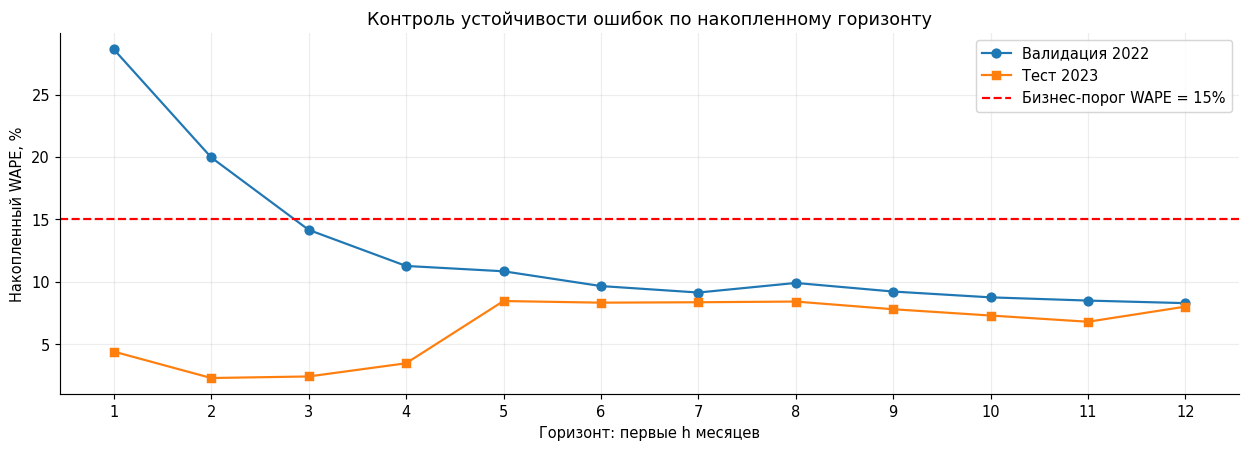

Максимальный прошедший критерий горизонт среди реально проверенных: 12 месяцев.
На 12 месяцах: WAPE(2022)=8.3%, WAPE(2023)=8.0%, R2(2022)=0.586, R2(2023)=0.512.


In [77]:
val_point=validation_preds[chosen_name]
test_point=test_predictions[chosen_name]
H=12
horizon_rows=[]
for h in range(1,H+1):
    ev_val=evaluation(valid.iloc[:h],val_point.iloc[:h])
    ev_test=evaluation(test.iloc[:h],test_point.iloc[:h])
    horizon_rows.append({'Горизонт, мес.':h,'WAPE на 2022, %':ev_val['WAPE, %'],
                         'WAPE на 2023, %':ev_test['WAPE, %'],
                         'R2 на 2022':ev_val['R2'] if h>=3 else np.nan,
                         'R2 на 2023':ev_test['R2'] if h>=3 else np.nan})
horizon_quality=pd.DataFrame(horizon_rows)
display(horizon_quality.round(3))

fig,ax=plt.subplots(figsize=(12,4.4))
ax.plot(horizon_quality['Горизонт, мес.'],horizon_quality['WAPE на 2022, %'],marker='o',label='Валидация 2022')
ax.plot(horizon_quality['Горизонт, мес.'],horizon_quality['WAPE на 2023, %'],marker='s',label='Тест 2023')
ax.axhline(15,color='red',ls='--',label='Бизнес-порог WAPE = 15%')
ax.set(xticks=range(1,13),xlabel='Горизонт: первые h месяцев',ylabel='Накопленный WAPE, %',
       title='Контроль устойчивости ошибок по накопленному горизонту')
ax.legend();plt.tight_layout();plt.show()

allowed=horizon_quality[(horizon_quality['Горизонт, мес.']>=3)&
                        (horizon_quality['WAPE на 2022, %']<=15)&
                        (horizon_quality['WAPE на 2023, %']<=15)&
                        (horizon_quality['R2 на 2022']>0)&
                        (horizon_quality['R2 на 2023']>0)]
acceptable_h=int(allowed['Горизонт, мес.'].max()) if not allowed.empty else 0
print('Максимальный прошедший критерий горизонт среди реально проверенных:',acceptable_h,'месяцев.')
print(f'На 12 месяцах: WAPE(2022)={horizon_quality.iloc[-1]["WAPE на 2022, %"]:.1f}%, '
      f'WAPE(2023)={horizon_quality.iloc[-1]["WAPE на 2023, %"]:.1f}%, '
      f'R2(2022)={horizon_quality.iloc[-1]["R2 на 2022"]:.3f}, '
      f'R2(2023)={horizon_quality.iloc[-1]["R2 на 2023"]:.3f}.')

### Прогноз после последнего наблюдения (2024 год)

По завершении тестирования переобучаем ту же спецификацию, выбранную на 2022 году, на всём доступном ряде 2020–2023

Если максимальный прошедший проверку горизонт `acceptable_h > 0`, прогнозируем именно его (не более 12 месяцев). Если порог не пройден, формируем для прозрачности диагностический прогноз на 12 месяцев, но явно не называем его пригодным для принятия решений

,Прогноз продаж,Нижняя 95%,Верхняя 95%,Праздничный месяц
Месяц,,,,
2024-01-01,13329.0,11042.0,15615.0,0
2024-02-01,13954.0,11667.0,16240.0,0
2024-03-01,13337.0,11051.0,15623.0,0
2024-04-01,11563.0,9277.0,13850.0,0
2024-05-01,9694.0,7408.0,11981.0,0
2024-06-01,8897.0,6610.0,11183.0,0
2024-07-01,9465.0,7179.0,11751.0,0
2024-08-01,10661.0,8375.0,12947.0,0
2024-09-01,11498.0,9211.0,13784.0,0


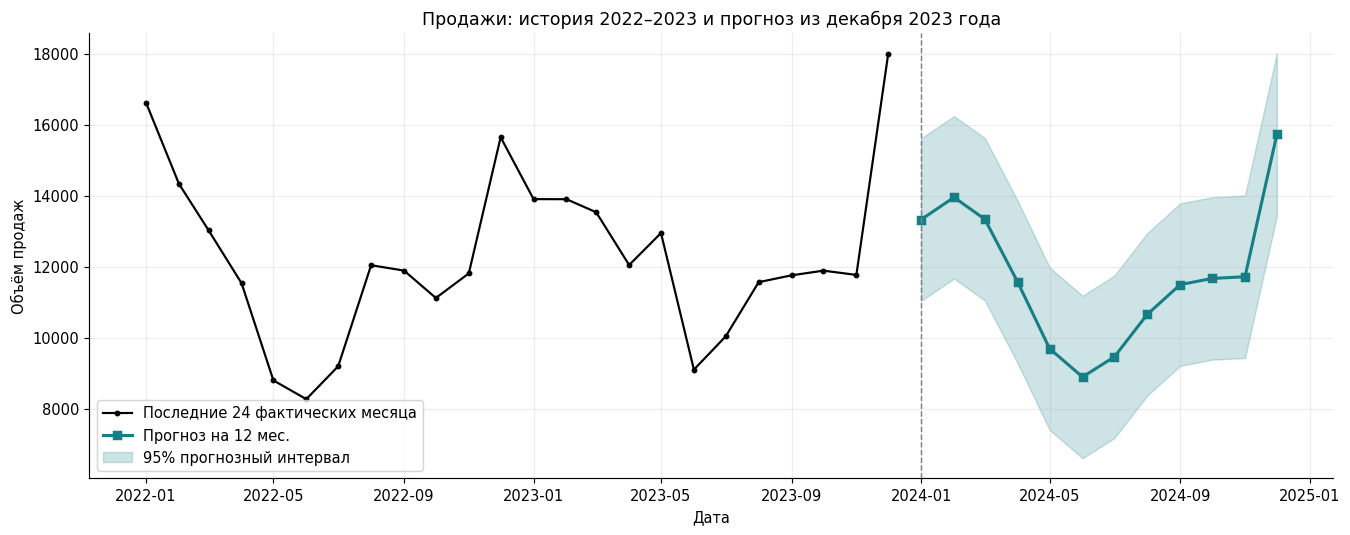

Метод: SARIMAX Фурье + декабрь
Период финального прогноза: 2024-01 — 2024-12
Сумма точечных месячных прогнозов за показанный период: 141,510.
Сумма границ отдельных месячных интервалов НЕ является корректным 95%-м интервалом для годовой суммы из-за корреляции месячных ошибок.
Статус: Горизонт прошёл установленные критерии.


In [79]:
final_fitted=fit_named(chosen_name,y)
future_dates=pd.date_range(y.index[-1]+pd.offsets.MonthBegin(1),periods=12,freq='MS')
future_pred_all,future_ci_all=forecast_named(chosen_name,final_fitted,future_dates)
if acceptable_h>0:
    future_pred=future_pred_all.iloc[:acceptable_h]
    future_ci=future_ci_all.iloc[:acceptable_h]
else:
    future_pred=future_pred_all
    future_ci=future_ci_all

future_table=pd.DataFrame({'Прогноз продаж':future_pred,
                           'Нижняя 95%':future_ci['Нижняя 95%'],
                           'Верхняя 95%':future_ci['Верхняя 95%'],
                           'Праздничный месяц':(future_pred.index.month==12).astype(int)})
future_table.index.name='Месяц'
display(future_table.round(0))

fig,ax=plt.subplots(figsize=(13,5.2))
ax.plot(y.iloc[-24:],marker='o',ms=3,color='black',label='Последние 24 фактических месяца')
ax.plot(future_pred,marker='s',color='#167e85',lw=2.1,label=f'Прогноз на {len(future_pred)} мес.')
ax.fill_between(future_ci.index,future_ci['Нижняя 95%'].values,
                future_ci['Верхняя 95%'].values,alpha=.21,color='#167e85',
                label='95% прогнозный интервал')
ax.axvline(future_dates.min(),ls='--',color='grey',lw=1)
ax.set(title='Продажи: история 2022–2023 и прогноз из декабря 2023 года',
       xlabel='Дата',ylabel='Объём продаж')
ax.legend();plt.tight_layout();plt.show()

print('Метод:',chosen_name)
print('Период финального прогноза:',future_pred.index.min().strftime('%Y-%m'),'—',
      future_pred.index.max().strftime('%Y-%m'))
print(f'Сумма точечных месячных прогнозов за показанный период: {future_pred.sum():,.0f}.')
print('Сумма границ отдельных месячных интервалов НЕ является корректным '
      '95%-м интервалом для годовой суммы из-за корреляции месячных ошибок.')
print('Статус:', 'Горизонт прошёл установленные критерии.' if acceptable_h>0 else
      'Горизонт НЕ прошёл установленные критерии, прогноз иллюстративный.')